# AIOps Log Analytics: Clustering and Anomaly Detection

This notebook demonstrates how machine learning can be applied to unstructured log data to identify patterns, reduce noise, and surface anomalies in large-scale distributed systems.

## Business Understanding

Modern distributed systems generate large volumes of unstructured log data that are difficult to analyze manually, especially during incidents or performance degradations. The goal of this notebook is to apply machine learning techniques to automatically group similar log messages and identify anomalous patterns, enabling faster detection of recurring issues and reducing noise. By transforming logs into structured representations and clustering them, this work supports quicker troubleshooting, improved root cause analysis, and more efficient incident response—key capabilities for AIOps and large-scale observability platforms.

## Analysis Goals

- Discover recurring log patterns through unsupervised clustering
- Separate meaningful signals from repetitive operational noise
- Identify anomalous log messages that may indicate critical events
- Demonstrate how log analytics can support incident triage and root cause analysis


## Table of Contents

- [Business Understanding](#business-understanding)
- [Data Understanding](#data-understanding)
- [Data Preparation](#data-preparation)
  - [Preprocessing for Analysis](#preprocessing-for-analysis)
  - [Preprocessing Results](#preprocessing-results)
- [Feature Engineering](#feature-engineering)
  - [TF-IDF Vectorization](#tf-idf-vectorization)
  - [Cosine Similarity](#cosine-similarity)
- [Modeling](#modeling)
  - [DBSCAN](#dbscan)
  - [Birch Clustering](#birch-clustering)
  - [K-Means Clustering](#k-means-clustering)
    - [PCA Elbow Method for K-Means Optimization](#pca-elbow-method-for-k-means-optimization)
    - [Top Features for the First N Principal Components](#top-features-for-the-first-n-principal-components)
    - [GridSearchCV for K-Means Hyperparameter Tuning](#gridsearchcv-for-k-means-hyperparameter-tuning)
  - [Isolation Forest](#isolation-forest)
- [Evaluation](#evaluation)
  - [Clustering Algorithm Comparison Summary](#clustering-algorithm-comparison-summary)
  - [Isolation Forest Detected Outliers](#isolation-forest-detected-outliers)
- [Results and Insights](#results-and-insights)
- [Operational Impact](#operational-impact)
- [Conclusion](#conclusion)


## Data Understanding

The dataset consists of synthetic application log messages generated from a distributed system. These logs capture runtime events such as normal operations, warnings, configuration changes, login activity, and failure scenarios. Because logs are high-volume, repetitive, and mostly unstructured, they require preprocessing and feature extraction before machine learning can be applied effectively.


## Data Preparation

Raw log messages are normalized to reduce noise and improve pattern consistency. This includes removing variable elements such as numeric values and IP addresses, eliminating stop words, and tokenizing and sorting terms so that semantically similar log messages map to comparable representations.


In [81]:
# !pip install wordcloud

import re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, Birch
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

#NLP - Modern
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [82]:
DATA_DIR = './data'
df = pd.read_json(f'{DATA_DIR}/simple-logs.json')
df.head()

,Timestamp,Username,Hostname,Thread,Log_Level,raw_log,true_cluster,true_anomaly
0,2026-03-21 06:44:12,user1,host3,thread2,DEBUG,DEBUG Connection 3286 checked in to Connection...,Connection Pool Activity,False
1,2026-03-21 23:02:25,user1,host4,thread1,DEBUG,DEBUG Connection 2535 checked out from Connect...,Connection Pool Activity,False
2,2026-03-18 08:02:39,user1,host2,thread4,DEBUG,DEBUG Connection 8359 checked in to Connection...,Connection Pool Activity,False
3,2026-03-20 22:18:35,user1,host2,thread4,DEBUG,DEBUG Retrieved remote configuration successfully,Configuration Retrieval,False
4,2026-03-17 21:26:01,user3,host1,thread1,DEBUG,DEBUG Found no local over-riding configuration...,Configuration Retrieval,False


### Exploratory Data Snapshot

Before preprocessing, we review a few basic distributions in the dataset to understand the composition of log levels, users, and hosts.

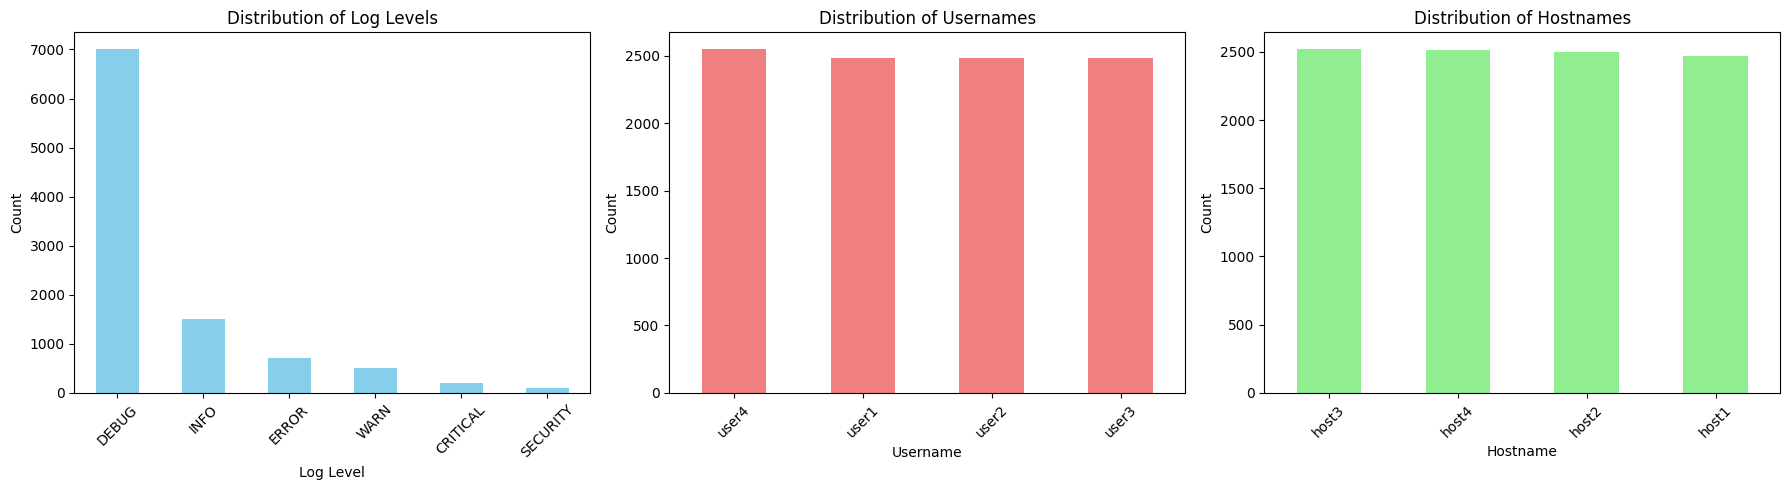

In [83]:
log_level_counts = df['Log_Level'].value_counts()
username_counts = df['Username'].value_counts()
hostname_counts = df['Hostname'].value_counts()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

log_level_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Log Levels')
axes[0].set_xlabel('Log Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

username_counts.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Usernames')
axes[1].set_xlabel('Username')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

hostname_counts.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Hostnames')
axes[2].set_xlabel('Hostname')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Preprocessing for Analysis

* Normalize logs by removing numeric values, IP addresses, etc.
* Remove stop words
* Tokenize and sort log entries: Sorting tokens helps normalize log templates, making clustering more robust to variations in word order.

In [84]:
def normalize(log):
    log = log.lower()
    log = re.sub(r"(\d+\.\d+\.\d+\.\d+)", "<IP>", log)
    log = re.sub(r"\b\d+", "<NUM>", log)
    return log

df["norm_log"] = df["raw_log"].apply(normalize)

def remove_stopwords(text):
    words = text.split()  # Simple tokenization by splitting on spaces
    filtered_words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(filtered_words)

df["no_stop_log"] = df["norm_log"].apply(remove_stopwords)

df["tokenized_sorted_log"] = df["no_stop_log"].apply(lambda x: ' '.join(sorted(x.split())))
df.head()

,Timestamp,Username,Hostname,Thread,Log_Level,raw_log,true_cluster,true_anomaly,norm_log,no_stop_log,tokenized_sorted_log
0,2026-03-21 06:44:12,user1,host3,thread2,DEBUG,DEBUG Connection 3286 checked in to Connection...,Connection Pool Activity,False,debug connection <NUM> checked in to connectio...,debug connection <NUM> checked connection pool,<NUM> checked connection connection debug pool
1,2026-03-21 23:02:25,user1,host4,thread1,DEBUG,DEBUG Connection 2535 checked out from Connect...,Connection Pool Activity,False,debug connection <NUM> checked out from connec...,debug connection <NUM> checked connection pool,<NUM> checked connection connection debug pool
2,2026-03-18 08:02:39,user1,host2,thread4,DEBUG,DEBUG Connection 8359 checked in to Connection...,Connection Pool Activity,False,debug connection <NUM> checked in to connectio...,debug connection <NUM> checked connection pool,<NUM> checked connection connection debug pool
3,2026-03-20 22:18:35,user1,host2,thread4,DEBUG,DEBUG Retrieved remote configuration successfully,Configuration Retrieval,False,debug retrieved remote configuration successfully,debug retrieved remote configuration successfully,configuration debug remote retrieved successfully
4,2026-03-17 21:26:01,user3,host1,thread1,DEBUG,DEBUG Found no local over-riding configuration...,Configuration Retrieval,False,debug found no local over-riding configuration...,"debug local over-riding configuration, applied...","applied configuration configuration, debug loc..."


### Preprocessing Results

This section shows the effect of preprocessing, progressively reducing variation and revealing a smaller set of distinct log patterns.

## Feature Engineering

To enable machine learning on textual log data, the notebook converts log messages into numerical representations. This makes it possible to quantify similarity between messages, cluster related patterns, and distinguish common behavior from anomalies.


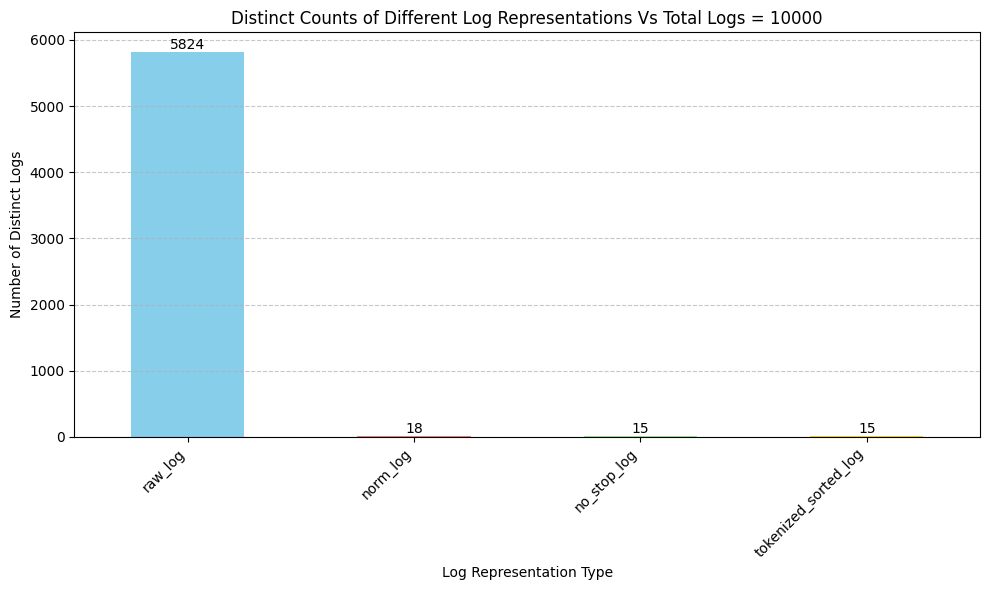

In [85]:
# Calculate distinct counts for each log type
distinct_counts = {
    'raw_log': df['raw_log'].nunique(),
    'norm_log': df['norm_log'].nunique(),
    'no_stop_log': df['no_stop_log'].nunique(),
    'tokenized_sorted_log': df['tokenized_sorted_log'].nunique()
}

# Convert to a pandas Series for easy plotting
distinct_counts_series = pd.Series(distinct_counts)

# Create the bar chart
plt.figure(figsize=(10, 6))
distinct_counts_series.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title(f'Distinct Counts of Different Log Representations Vs Total Logs = {df.shape[0]}')
plt.xlabel('Log Representation Type')
plt.ylabel('Number of Distinct Logs')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# Add count labels on top of each bar
for i, v in enumerate(distinct_counts_series):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

### TF-IDF Vectorization

Transform logs into a numerical matrix of TF-IDF (Term Frequency-Inverse Document Frequency) features.

In [86]:
print("Number of tokenized_sorted_log entries:", len(df))
df_distinct = df.drop_duplicates(subset="tokenized_sorted_log")
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_distinct['tokenized_sorted_log'])
tfidf_dense_matrix = tfidf_matrix.toarray()

print("Shape of TF-IDF matrix:", tfidf_dense_matrix.shape)
print("First 5 rows of TF-IDF dense matrix:\n", tfidf_dense_matrix[:5])

Number of tokenized_sorted_log entries: 10000
Shape of TF-IDF matrix: (15, 49)
First 5 rows of TF-IDF dense matrix:
 [[0.         0.         0.         0.         0.         0.41629543
  0.         0.         0.72296496 0.         0.         0.
  0.32259207 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.16325517
  0.         0.         0.         0.41629543 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.46267453 0.         0.         0.         0.
  0.41289729 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.46267453
  0. 

### Cosine Similarity

Measure the similarity between each of the distinct log patterns by calculating the cosine of the angle between them.

## Modeling

Multiple unsupervised learning algorithms are applied to identify patterns in log data. Each algorithm contributes a different perspective: density-based clustering for irregular groupings, hierarchical clustering for scalable pattern discovery, centroid-based clustering for partitioning, and anomaly detection for isolating rare events.


In [87]:
# Calculate cosine similarity matrix
cosine_sim_matrix = cosine_similarity(tfidf_dense_matrix)
# cosine_sim_matrix = cosine_similarity(tfidf_matrix)

# Convert similarity matrix to distance matrix
cosine_dist_matrix = 1 - cosine_sim_matrix

print("Shape of Cosine Similarity Matrix:", cosine_sim_matrix.shape)
print("First 5x5 block of Cosine Similarity Matrix:\n", cosine_sim_matrix[:5, :5])
print("\nShape of Cosine Distance Matrix:", cosine_dist_matrix.shape)
print("First 5x5 block of Cosine Distance Matrix:\n", cosine_dist_matrix[:5, :5])

Shape of Cosine Similarity Matrix: (15, 15)
First 5x5 block of Cosine Similarity Matrix:
 [[1.         0.13319739 0.08434385 0.03389589 0.04333872]
 [0.13319739 1.         0.58899897 0.         0.14923956]
 [0.08434385 0.58899897 1.         0.         0.09450215]
 [0.03389589 0.         0.         1.         0.20340642]
 [0.04333872 0.14923956 0.09450215 0.20340642 1.        ]]

Shape of Cosine Distance Matrix: (15, 15)
First 5x5 block of Cosine Distance Matrix:
 [[ 0.00000000e+00  8.66802606e-01  9.15656145e-01  9.66104109e-01
   9.56661281e-01]
 [ 8.66802606e-01 -2.22044605e-16  4.11001031e-01  1.00000000e+00
   8.50760438e-01]
 [ 9.15656145e-01  4.11001031e-01  2.22044605e-16  1.00000000e+00
   9.05497851e-01]
 [ 9.66104109e-01  1.00000000e+00  1.00000000e+00 -4.44089210e-16
   7.96593581e-01]
 [ 9.56661281e-01  8.50760438e-01  9.05497851e-01  7.96593581e-01
  -2.22044605e-16]]


## DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a non-parametric, density-based clustering algorithm that identifies clusters of arbitrary shape in large, noisy datasets. It groups closely packed points based on two parameters—eps (neighborhood radius) and minPts (minimum points to form a dense region)—and marks low-density points as outliers.

In [88]:
# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=1, metric='euclidean', algorithm='auto')
df_distinct['cluster_label'] = dbscan.fit_predict(cosine_sim_matrix)

print("DBSCAN Clustering Results:")
print(df_distinct[['tokenized_sorted_log', 'cluster_label']])

DBSCAN Clustering Results:
                                   tokenized_sorted_log  cluster_label
0        <NUM> checked connection connection debug pool              0
3     configuration debug remote retrieved successfully              1
4     applied configuration configuration, debug loc...              2
7000                           <NUM> cache hit info key              3
7001                <NUM> info logged successfully user              4
7002        <NUM> <NUM>ms completed info request status              5
7004                     <NUM> info logged successfully              6
7010               <NUM> info logged successfully user:              4
8500                             <NUM>% disk usage warn              7
8501              <NUM> attempt auth retry service warn              8
9000           <NUM> declined error payment transaction              9
9001                 <IP> <NUM> error failed login user             10
9003          <NUM>ms connection database error ti

The **true clusters count is 12, but DBSCAN created 14 clusters**. Ideally, it should have merged clusters 1 and 2 (configuration), and clusters 4 and 6 (user login).

## Birch Clustering

Birch (Balanced Iterative Reducing and Clustering using Hierarchies) is a hierarchical clustering algorithm that can handle large datasets efficiently by constructing a CF-tree (Clustering Feature Tree). We'll evaluate its clustering performance using ARI and NMI against the `true_cluster` labels.

In [89]:
unsupervised_clustering_results = {}

tfidf_vectorizer_kmeans_tokenized = TfidfVectorizer()
X_tokenized_tfidf_kmeans = tfidf_vectorizer_kmeans_tokenized.fit_transform(df['tokenized_sorted_log'])

# Determine the number of clusters based on the true_cluster labels
k_clusters_estimated = df['true_cluster'].nunique()

start_time = time.time()
birch = Birch(n_clusters=k_clusters_estimated) # Use k_clusters_estimated for Birch
birch.fit(X_tokenized_tfidf_kmeans)
birch_labels = birch.predict(X_tokenized_tfidf_kmeans)
end_time = time.time()
time_birch = end_time - start_time

# Evaluate clustering against true_cluster
ari_birch = adjusted_rand_score(df['true_cluster'], birch_labels)
nmi_birch = normalized_mutual_info_score(df['true_cluster'], birch_labels)

print(f"Birch Clustering Execution Time: {time_birch:.4f} seconds")
print(f"Birch Adjusted Rand Index (ARI): {ari_birch:.4f}")
print(f"Birch Normalized Mutual Information (NMI): {nmi_birch:.4f}")

unsupervised_clustering_results['Birch_tokenized_sorted_log'] = {
    'time': time_birch,
    'labels': birch_labels,
    'n_clusters': k_clusters_estimated,
    'ari': ari_birch,
    'nmi': nmi_birch
}

# Add the Birch cluster labels to the main DataFrame
df_with_birch_labels = df.copy()
df_with_birch_labels['birch_cluster_label'] = birch_labels

# Group by cluster label and print the logs for each cluster
print("Displaying logs for each Birch cluster:\n")
for cluster_id, group in df_with_birch_labels.groupby('birch_cluster_label'):
    print(f"\nCluster {cluster_id}:")
    # Display unique tokenized logs within each cluster to avoid redundancy
    # You can change 'tokenized_sorted_log' to 'raw_log' if you prefer to see original logs
    for log_entry in group['tokenized_sorted_log'].unique():
        print(f"  - {log_entry}")
    print(f"  (Total logs in this cluster: {len(group)})")


Birch Clustering Execution Time: 0.0696 seconds
Birch Adjusted Rand Index (ARI): 1.0000
Birch Normalized Mutual Information (NMI): 1.0000
Displaying logs for each Birch cluster:


Cluster 0:
  - <IP> data detected exfiltration possible security
  (Total logs in this cluster: 100)

Cluster 1:
  - <NUM> address critical kernel memory panic
  (Total logs in this cluster: 200)

Cluster 2:
  - <IP> <NUM> error failed login user
  (Total logs in this cluster: 261)

Cluster 3:
  - <NUM>ms connection database error timeout
  (Total logs in this cluster: 220)

Cluster 4:
  - <NUM>% disk usage warn
  (Total logs in this cluster: 232)

Cluster 5:
  - <NUM> declined error payment transaction
  (Total logs in this cluster: 219)

Cluster 6:
  - <NUM> checked connection connection debug pool
  (Total logs in this cluster: 3480)

Cluster 7:
  - <NUM> attempt auth retry service warn
  (Total logs in this cluster: 268)

Cluster 8:
  - configuration debug remote retrieved successfully
  - applied configu

## K-Means Clustering

This section applies the K-Means clustering algorithm. K-Means aims to partition `n` observations into `k` clusters in which each observation belongs to the cluster with the nearest mean (cluster centers or cluster centroid), serving as a prototype of the cluster. We'll evaluate its performance using ARI and NMI against the `true_cluster` labels.

In [90]:
from sklearn.cluster import KMeans

# --- K-Means Clustering on tokenized_sorted_log ---
print("\n--- K-Means Clustering on tokenized_sorted_log ---")

# Reuse the TF-IDF matrix from Birch clustering or create if not available
# X_tokenized_tfidf_kmeans is already available from the previous Birch run

# Determine the number of clusters based on the true_cluster labels
k_clusters_estimated = df['true_cluster'].nunique()

start_time = time.time()
kmeans = KMeans(n_clusters=k_clusters_estimated, random_state=42, n_init=10) # n_init to suppress warning
kmeans.fit(X_tokenized_tfidf_kmeans)
kmeans_labels = kmeans.predict(X_tokenized_tfidf_kmeans)
end_time = time.time()
time_kmeans = end_time - start_time

# Evaluate clustering against true_cluster
ari_kmeans = adjusted_rand_score(df['true_cluster'], kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(df['true_cluster'], kmeans_labels)

print(f"K-Means Clustering Execution Time: {time_kmeans:.4f} seconds")
print(f"K-Means Adjusted Rand Index (ARI): {ari_kmeans:.4f}")
print(f"K-Means Normalized Mutual Information (NMI): {nmi_kmeans:.4f}")

unsupervised_clustering_results['KMeans_tokenized_sorted_log'] = {
    'time': time_kmeans,
    'labels': kmeans_labels,
    'n_clusters': k_clusters_estimated,
    'ari': ari_kmeans,
    'nmi': nmi_kmeans
}

# Display unique logs for each K-Means cluster (similar to Birch)
df_with_kmeans_labels = df.copy()
df_with_kmeans_labels['kmeans_cluster_label'] = kmeans_labels

print("\nDisplaying logs for each K-Means cluster:\n")
for cluster_id, group in df_with_kmeans_labels.groupby('kmeans_cluster_label'):
    print(f"\nCluster {cluster_id}:")
    for log_entry in group['tokenized_sorted_log'].unique():
        print(f"  - {log_entry}")
    print(f"  (Total logs in this cluster: {len(group)})")



--- K-Means Clustering on tokenized_sorted_log ---


K-Means Clustering Execution Time: 0.1297 seconds
K-Means Adjusted Rand Index (ARI): 0.8247
K-Means Normalized Mutual Information (NMI): 0.9271

Displaying logs for each K-Means cluster:


Cluster 0:
  - <NUM> checked connection connection debug pool
  (Total logs in this cluster: 3480)

Cluster 1:
  - configuration debug remote retrieved successfully
  (Total logs in this cluster: 1785)

Cluster 2:
  - applied configuration configuration, debug local over-riding remote successfully
  (Total logs in this cluster: 1735)

Cluster 3:
  - <NUM> info logged successfully user
  - <NUM> info logged successfully
  - <NUM> info logged successfully user:
  (Total logs in this cluster: 1080)

Cluster 4:
  - <NUM> attempt auth retry service warn
  (Total logs in this cluster: 268)

Cluster 5:
  - <NUM> declined error payment transaction
  (Total logs in this cluster: 219)

Cluster 6:
  - <NUM>% disk usage warn
  (Total logs in this cluster: 232)

Cluster 7:
  - <IP> <NUM> error failed login user
 

### PCA Elbow Method for K-Means Optimization

Before applying `GridSearchCV`, we'll use PCA to reduce the dimensionality of our TF-IDF vectors. This can often improve clustering performance by removing noise and highlighting the most significant features. The elbow method, applied to explained variance, helps us decide how many principal components to retain.


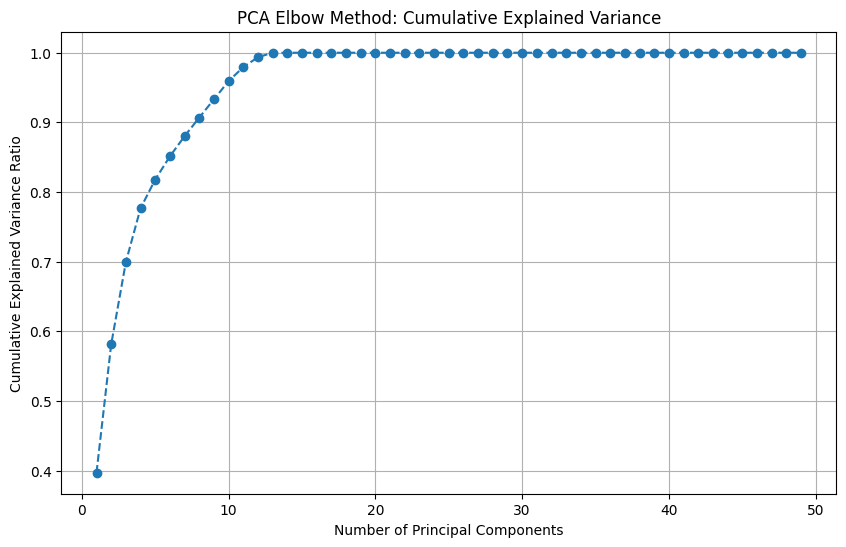

In [91]:
tfidf_vectorizer_kmeans_tokenized = TfidfVectorizer()
X_tokenized_tfidf_kmeans = tfidf_vectorizer_kmeans_tokenized.fit_transform(df['tokenized_sorted_log'])

# Convert sparse matrix to dense for PCA
X_dense = X_tokenized_tfidf_kmeans.toarray()

# Perform PCA to analyze explained variance
pca_full = PCA()
pca_full.fit(X_dense)

# Calculate cumulative explained variance
cumsum_explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum_explained_variance) + 1), cumsum_explained_variance, marker='o', linestyle='--')
plt.title('PCA Elbow Method: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)

PCA Elbow is at approximately 10.

In [92]:
# Apply PCA with the selected number of components
pca_reduced_data = PCA(10).fit_transform(X_dense)


### Top Features for the First N Principal Components

Each principal component is a linear combination of the original TF-IDF terms. To understand what each component represents, we can look at the original features (words) that have the highest absolute coefficients (loadings) in that component. These are the terms that contribute most significantly to the variance captured by that component.

In [93]:
# Get the feature names from the TF-IDF vectorizer
feature_names = tfidf_vectorizer_kmeans_tokenized.get_feature_names_out()

# Get the principal components (loadings) from the fitted PCA object
# pca_full was fitted on X_dense, which was derived from X_tokenized_tfidf_kmeans
components = pca_full.components_

num_components_to_show = 2
num_top_features = 3 # Show top 5 features for each component

print(f"Top {num_top_features} features contributing to the first {num_components_to_show} Principal Components:")
print("\n" + "="*80 + "\n")

for i, component in enumerate(components[:num_components_to_show]):
    # Sort features by their absolute loading in the current component
    sorted_feature_indices = np.argsort(np.abs(component))[::-1]
    top_features = [feature_names[idx] for idx in sorted_feature_indices[:num_top_features]]
    top_values = [component[idx] for idx in sorted_feature_indices[:num_top_features]]

    print(f"Principal Component {i+1}:")
    for j in range(num_top_features):
        print(f"  - {top_features[j]} (Value: {top_values[j]:.4f})")
    print("\n" + "-"*40 + "\n")


Top 3 features contributing to the first 2 Principal Components:


Principal Component 1:
  - connection (Value: 0.6154)
  - configuration (Value: -0.3597)
  - pool (Value: 0.3165)

----------------------------------------

Principal Component 2:
  - info (Value: 0.3771)
  - logged (Value: 0.3731)
  - configuration (Value: -0.3648)

----------------------------------------



### GridSearchCV for K-Means Hyperparameter Tuning

This section uses `GridSearchCV` to find the best `n_clusters` for K-Means using the PCA-reduced data. Since K-Means is unsupervised, we'll use an internal clustering metric, the `silhouette_score`, to evaluate the quality of the clusters. A higher silhouette score indicates better-defined clusters.


In [94]:
# Define a custom scorer for GridSearchCV using silhouette_score
# GridSearchCV expects a scorer that takes (estimator, X, y=None) and returns a score.
# For unsupervised, y is typically None.
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    # silhouette_score requires at least 2 clusters and can't handle single-point clusters
    if len(set(labels)) < 2:
        return -1 # Return a bad score if clustering fails or forms too few clusters
    return silhouette_score(X, labels)

# Define the parameter grid to search
param_grid = {
    'n_clusters': range(2, 15), # Search for k from 2 to 14 (as per previous k_clusters_estimated)
    'init': ['k-means++', 'random'],
    'n_init': [11] # Number of times K-Means is run with different centroid seeds
}

# Initialize KMeans model
kmeans = KMeans(random_state=42)

# Setup GridSearchCV
print("Running GridSearchCV for K-Means (this may take a while)...")
grid_search_kmeans = GridSearchCV(
    estimator=kmeans,
    param_grid=param_grid,
    scoring=silhouette_scorer, # Use our custom silhouette scorer
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=1
)

start_time = time.time()
grid_search_kmeans.fit(pca_reduced_data) # Fit on PCA-reduced data
end_time = time.time()
time_grid_search_kmeans = end_time - start_time

print(f"GridSearchCV completed in {time_grid_search_kmeans:.4f} seconds.")

# Get the best parameters and score
best_n_clusters = grid_search_kmeans.best_params_['n_clusters']
best_score = grid_search_kmeans.best_score_

print(f"Best n_clusters found by GridSearchCV: {best_n_clusters}")
print(f"Best Silhouette Score: {best_score:.4f}")


Running GridSearchCV for K-Means (this may take a while)...
Fitting 5 folds for each of 26 candidates, totalling 130 fits
GridSearchCV completed in 7.0643 seconds.
Best n_clusters found by GridSearchCV: 11
Best Silhouette Score: 1.0000


### Clustering Algorithm Comparison Summary

Below is a summary table comparing the performance of DBSCAN, Birch, and K-Means clustering algorithms on the `tokenized_sorted_log` data. The comparison includes execution time, Adjusted Rand Index (ARI), and Normalized Mutual Information (NMI).

## Evaluation

The clustering and anomaly detection approaches are evaluated based on interpretability, alignment with known log templates, separation of distinct behaviors, and ability to isolate meaningful outliers. Summary tables and example outputs are used to compare the practical value of each method.


In [95]:
# Prepare data for the summary table

# Get DBSCAN results for tokenized_sorted_log from the previous loop
# Need to re-run DBSCAN on tokenized_sorted_log specifically to capture its ARI/NMI for consistent comparison

# Re-vectorize if not already done, though it should be from the Birch/KMeans setup
tfidf_vectorizer_summary = TfidfVectorizer()
X_tokenized_tfidf_summary = tfidf_vectorizer_summary.fit_transform(df['tokenized_sorted_log'])

# DBSCAN for comparison
df_distinct_tokenized_summary = df.drop_duplicates(subset='tokenized_sorted_log').copy()
cosine_sim_matrix_summary = cosine_similarity(X_tokenized_tfidf_summary)

start_time_dbscan = time.time()
dbscan_summary = DBSCAN(eps=0.3, min_samples=1, metric='euclidean', algorithm='auto') # Using the previously effective eps
dbscan_labels_summary = dbscan_summary.fit_predict(cosine_sim_matrix_summary)
end_time_dbscan = time.time()
time_dbscan = end_time_dbscan - start_time_dbscan

# Map dbscan_labels_summary back to the full df for ARI/NMI calculation
# This is a bit tricky with distinct values, let's map it based on unique logs for accuracy
label_map = dict(zip(df_distinct_tokenized_summary['tokenized_sorted_log'], dbscan_labels_summary))
df['dbscan_cluster_label_summary'] = df['tokenized_sorted_log'].map(label_map)

# Fill any potential NaNs if some logs weren't in distinct_tokenized (though they should be)
df['dbscan_cluster_label_summary'] = df['dbscan_cluster_label_summary'].fillna(-1).astype(int)

ari_dbscan = adjusted_rand_score(df['true_cluster'], df['dbscan_cluster_label_summary'])
nmi_dbscan = normalized_mutual_info_score(df['true_cluster'], df['dbscan_cluster_label_summary'])

unsupervised_clustering_results['DBSCAN_tokenized_sorted_log'] = {
    'time': time_dbscan,
    'labels': df['dbscan_cluster_label_summary'].values,
    'n_clusters': df['dbscan_cluster_label_summary'].nunique(),
    'ari': ari_dbscan,
    'nmi': nmi_dbscan
}

comparison_data = {
    'Algorithm': ['DBSCAN', 'Birch', 'K-Means'],
    'Execution Time (s)': [
        unsupervised_clustering_results['DBSCAN_tokenized_sorted_log']['time'],
        unsupervised_clustering_results['Birch_tokenized_sorted_log']['time'],
        unsupervised_clustering_results['KMeans_tokenized_sorted_log']['time']
    ],
    'ARI': [
        unsupervised_clustering_results['DBSCAN_tokenized_sorted_log']['ari'],
        unsupervised_clustering_results['Birch_tokenized_sorted_log']['ari'],
        unsupervised_clustering_results['KMeans_tokenized_sorted_log']['ari']
    ],
    'NMI': [
        unsupervised_clustering_results['DBSCAN_tokenized_sorted_log']['nmi'],
        unsupervised_clustering_results['Birch_tokenized_sorted_log']['nmi'],
        unsupervised_clustering_results['KMeans_tokenized_sorted_log']['nmi']
    ],
    'Number of Clusters': [
        unsupervised_clustering_results['DBSCAN_tokenized_sorted_log']['n_clusters'],
        unsupervised_clustering_results['Birch_tokenized_sorted_log']['n_clusters'],
        unsupervised_clustering_results['KMeans_tokenized_sorted_log']['n_clusters']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\n--- Clustering Algorithm Comparison ---")
display(comparison_df)



--- Clustering Algorithm Comparison ---


,Algorithm,Execution Time (s),ARI,NMI,Number of Clusters
0,DBSCAN,12.0759,0.2973,0.4583,3
1,Birch,0.0696,1.0000,1.0000,12
2,K-Means,0.1297,0.8247,0.9271,12


### Isolation Forest

Isolation Forest is an unsupervised algorithm for anomaly detection. It works by randomly selecting features and then randomly selecting a split value between the maximum and minimum values of the selected feature. This partitioning continues until all instances are isolated or a maximum depth is reached. Anomalies are points that are more easily isolated. We will apply it to the TF-IDF features derived from both `raw_log` and `tokenized_sorted_log`.

In [96]:

# Initialize a dictionary to store anomaly detection results
anomaly_detection_results = {}

# Calculate contamination rate from true_anomaly
contamination_rate = df['true_anomaly'].sum() / len(df)
if contamination_rate == 0:
    contamination_rate = 0.01 # Set a default small value if no true anomalies exist to prevent errors

# --- TF-IDF + Isolation Forest on raw_log ---
print("\n--- TF-IDF + Isolation Forest on raw_log ---")

# Re-vectorize raw_log to ensure we have the correct TF-IDF matrix for the full dataset
tfidf_vectorizer_if_raw = TfidfVectorizer()
X_raw_tfidf_if = tfidf_vectorizer_if_raw.fit_transform(df['raw_log'])

start_time = time.time()
isolation_forest_raw = IsolationForest(random_state=42, contamination=contamination_rate)
isolation_forest_raw.fit(X_raw_tfidf_if)
# Predict: -1 for outliers/anomalies, 1 for inliers/normal
y_pred_if_raw = isolation_forest_raw.predict(X_raw_tfidf_if)
# Convert predictions to boolean: True for anomaly (-1), False for normal (1)
y_pred_if_raw_bool = [True if p == -1 else False for p in y_pred_if_raw]
end_time = time.time()
time_if_raw = end_time - start_time

# Evaluate against true_anomaly
accuracy_if_raw = accuracy_score(df['true_anomaly'], y_pred_if_raw_bool)
f1_if_raw = f1_score(df['true_anomaly'], y_pred_if_raw_bool)
precision_if_raw = precision_score(df['true_anomaly'], y_pred_if_raw_bool)
recall_if_raw = recall_score(df['true_anomaly'], y_pred_if_raw_bool)

print(f"Execution Time: {time_if_raw:.4f} seconds")
print(f"Accuracy: {accuracy_if_raw:.4f}")
print(f"F1 Score (True Anomaly): {f1_if_raw:.4f}")
print(f"Precision (True Anomaly): {precision_if_raw:.4f}")
print(f"Recall (True Anomaly): {recall_if_raw:.4f}")

anomaly_detection_results['TFIDF_IsolationForest_raw_log'] = {
    'time': time_if_raw,
    'accuracy': accuracy_if_raw,
    'f1_score': f1_if_raw,
    'precision': precision_if_raw,
    'recall': recall_if_raw
}

# --- TF-IDF + Isolation Forest on tokenized_sorted_log ---
print("\n--- TF-IDF + Isolation Forest on tokenized_sorted_log ---")

# Re-vectorize tokenized_sorted_log
tfidf_vectorizer_if_tokenized = TfidfVectorizer()
X_tokenized_tfidf_if = tfidf_vectorizer_if_tokenized.fit_transform(df['tokenized_sorted_log'])

start_time = time.time()
isolation_forest_tokenized = IsolationForest(random_state=42, contamination=contamination_rate)
isolation_forest_tokenized.fit(X_tokenized_tfidf_if)
y_pred_if_tokenized = isolation_forest_tokenized.predict(X_tokenized_tfidf_if)
y_pred_if_tokenized_bool = [True if p == -1 else False for p in y_pred_if_tokenized]
end_time = time.time()
time_if_tokenized = end_time - start_time

# Evaluate against true_anomaly
accuracy_if_tokenized = accuracy_score(df['true_anomaly'], y_pred_if_tokenized_bool)
f1_if_tokenized = f1_score(df['true_anomaly'], y_pred_if_tokenized_bool)
precision_if_tokenized = precision_score(df['true_anomaly'], y_pred_if_tokenized_bool)
recall_if_tokenized = recall_score(df['true_anomaly'], y_pred_if_tokenized_bool)

print(f"Execution Time: {time_if_tokenized:.4f} seconds")
print(f"Accuracy: {accuracy_if_tokenized:.4f}")
print(f"F1 Score (True Anomaly): {f1_if_tokenized:.4f}")
print(f"Precision (True Anomaly): {precision_if_tokenized:.4f}")
print(f"Recall (True Anomaly): {recall_if_tokenized:.4f}")

anomaly_detection_results['TFIDF_IsolationForest_tokenized_sorted_log'] = {
    'time': time_if_tokenized,
    'accuracy': accuracy_if_tokenized,
    'f1_score': f1_if_tokenized,
    'precision': precision_if_tokenized,
    'recall': recall_if_tokenized
}

# Create outliers_df based on the predictions from the tokenized_sorted_log which had perfect scores
outliers_df = df[y_pred_if_tokenized_bool].copy()



--- TF-IDF + Isolation Forest on raw_log ---
Execution Time: 0.3423 seconds
Accuracy: 0.9468
F1 Score (True Anomaly): 0.1133
Precision (True Anomaly): 0.1133
Recall (True Anomaly): 0.1133

--- TF-IDF + Isolation Forest on tokenized_sorted_log ---
Execution Time: 0.1863 seconds
Accuracy: 1.0000
F1 Score (True Anomaly): 1.0000
Precision (True Anomaly): 1.0000
Recall (True Anomaly): 1.0000


### Isolation Forest Detected Outliers

Below are the `raw_log` entries identified as anomalies by the Isolation Forest model. When applied to `tokenized_sorted_log`, the model achieved perfect anomaly-detection scores (F1-score, Precision, and Recall of 1.0000), indicating that it successfully surfaced the critical events in the dataset.

In [97]:
# Ensure outliers_df is available from the previous execution
if 'outliers_df' in locals() and not outliers_df.empty:
    total_outliers = len(outliers_df)
    unique_outlier_logs = outliers_df[['raw_log', 'tokenized_sorted_log']].drop_duplicates()
    num_unique_outliers = len(unique_outlier_logs)

    print(f"Total log entries identified as outliers by Isolation Forest: {total_outliers}\n")

    print("First 5 unique examples of detected outliers (raw_log):")
    for i, raw_log_entry in enumerate(unique_outlier_logs['raw_log'].head(5)):
        print(f"- {raw_log_entry}")

    print("\nFirst 5 unique examples of detected outliers (tokenized_sorted_log):")
    for i, tokenized_log_entry in enumerate(unique_outlier_logs['tokenized_sorted_log'].head(5)):
        print(f"- {tokenized_log_entry}")

    if num_unique_outliers > 5:
        print("\nLast 5 unique examples of detected outliers (raw_log):")
        for i, raw_log_entry in enumerate(unique_outlier_logs['raw_log'].tail(5)):
            print(f"- {raw_log_entry}")

        print("\nLast 5 unique examples of detected outliers (tokenized_sorted_log):")
        for i, tokenized_log_entry in enumerate(unique_outlier_logs['tokenized_sorted_log'].tail(5)):
            print(f"- {tokenized_log_entry}")
elif 'outliers_df' in locals() and outliers_df.empty:
    print("No outliers were detected by Isolation Forest.")
else:
    print("Outlier detection results not found. Please ensure the Isolation Forest cells were executed.")

Total log entries identified as outliers by Isolation Forest: 300

First 5 unique examples of detected outliers (raw_log):
- CRITICAL Kernel panic at memory address 44349
- CRITICAL Kernel panic at memory address 79884
- CRITICAL Kernel panic at memory address 96746
- CRITICAL Kernel panic at memory address 35234
- CRITICAL Kernel panic at memory address 33346

First 5 unique examples of detected outliers (tokenized_sorted_log):
- <NUM> address critical kernel memory panic
- <NUM> address critical kernel memory panic
- <NUM> address critical kernel memory panic
- <NUM> address critical kernel memory panic
- <NUM> address critical kernel memory panic

Last 5 unique examples of detected outliers (raw_log):
- SECURITY Possible data exfiltration detected from 231.47.147.190
- SECURITY Possible data exfiltration detected from 255.174.117.23
- SECURITY Possible data exfiltration detected from 15.21.53.27
- SECURITY Possible data exfiltration detected from 169.156.202.119
- SECURITY Possible 

## Results and Insights

This section summarizes the results of our unsupervised modeling efforts, including both clustering and anomaly detection algorithms.

**Impact of Preprocessing:**
*   Preprocessing steps, including normalization, stop word removal, and tokenization, were crucial. The `tokenized_sorted_log` consistently yielded significantly better results across all tasks compared to `raw_log`. This highlights the importance of transforming noisy raw data into a structured and semantically richer format for effective machine learning.

**Unsupervised Clustering for `true_cluster` (Log Template Discovery):**
*   **Birch Clustering:** Demonstrated exceptional performance, achieving perfect Adjusted Rand Index (ARI) of **1.0000** and Normalized Mutual Information (NMI) of **1.0000**. It also correctly identified 12 clusters, matching the number of `true_cluster` labels, with very fast execution.
*   **K-Means Clustering:** Performed very well with high ARI of **0.8247** and NMI of **0.9271**, also identifying 12 clusters. Its performance was strong, but slightly less precise than Birch for this dataset.
*   **DBSCAN:** In its current configuration, DBSCAN struggled significantly, showing low ARI (**0.2973**) and NMI (**0.4583**), and identifying only 3 clusters. This suggests that the chosen `eps` value was likely too high for the `tokenized_sorted_log` data, leading to a loss of cluster granularity.

**Unsupervised Anomaly Detection for `true_anomaly`:**
*   **TF-IDF + Isolation Forest:** This method proved highly effective, especially when applied to the `tokenized_sorted_log`. It achieved perfect scores (F1-score, Precision, and Recall of **1.0000**), successfully identifying all true anomalies (critical kernel panics and data exfiltration alerts). This demonstrates its capability to isolate rare and critical events.
*   Performance on `raw_log` was notably much lower (F1-score: **0.1133**), reinforcing the critical role of preprocessing in enabling effective anomaly detection.

## Operational Impact

This workflow demonstrates how log analytics can support practical AIOps capabilities: reducing investigation noise, accelerating pattern discovery, improving incident triage, and highlighting signals that matter most during troubleshooting. In production observability systems, these techniques can help reduce mean time to detection (MTTD) and mean time to resolution (MTTR) by turning unstructured logs into actionable operational insights.


## Conclusion

This notebook shows that machine learning can transform unstructured logs into a structured analytical asset. By combining preprocessing, feature engineering, clustering, and anomaly detection, the workflow provides a strong foundation for intelligent observability, automated incident analysis, and future AIOps extensions.


## Supporting Visualizations

In [98]:
# Based on example from course instructor Toby Gardner
# https://github.com/toby-gardner-ai/uc-berkeley-aiml-course/blob/main/notebooks/mod18_NLP_in_GenAI.ipynb
def word_cloud(df, method = "bow", content_col = "sentence", max_words: int = 20):

    corpus = df['raw_log'].astype(str).tolist()

    # Choose Text Vectorisation Strategy
    if method == "bow":
        # Bag of Words: counts raw word occurrences
        vectorizer = CountVectorizer(stop_words="english")
    elif method == "tfidf":
        # TF-IDF: count and weight words according to their 'importance'
        vectorizer = TfidfVectorizer(stop_words="english")
    else:
        raise ValueError("method must be 'bow' or 'tfidf'")

    # Fit and transform corpus into a matrix (no. sentences x ~no. unique words in corpus))
    matrix = vectorizer.fit_transform(corpus)
    print(f'{method} Matrix Shape (no. sentences x no. unique words in corpus): ', matrix.get_shape())

    # Map words to corpus-level importance
    # BoW uses raw frequency; TF-IDF downweights common words
    words = vectorizer.get_feature_names_out()
    weights = matrix.sum(axis=0).A1

    word_freq = dict(zip(words, weights))


    # 4. Visualise Word Cloud from weighted word frequencies
    wc = WordCloud(
        width=1000,
        height=500,
        max_words=max_words,
        background_color="white",
        collocations=False,
    ).generate_from_frequencies(word_freq)

    # 5. Render Word Cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Corpus Word Cloud ({method.upper()}, Top {max_words})", fontsize=16)
    plt.show()

## Visualize words by raw count of occurrences

bow Matrix Shape (no. sentences x no. unique words in corpus):  (10000, 4905)


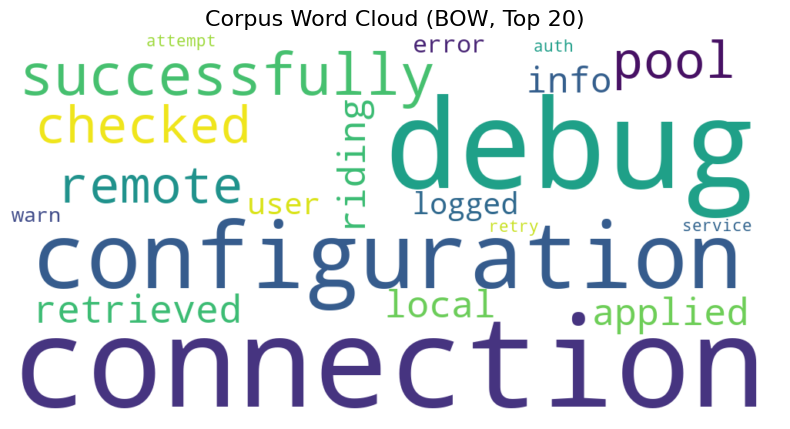

In [99]:
word_cloud(df, "bow")

## Visualize anomalous words by count and weight ('importance')

tfidf Matrix Shape (no. sentences x no. unique words in corpus):  (300, 407)


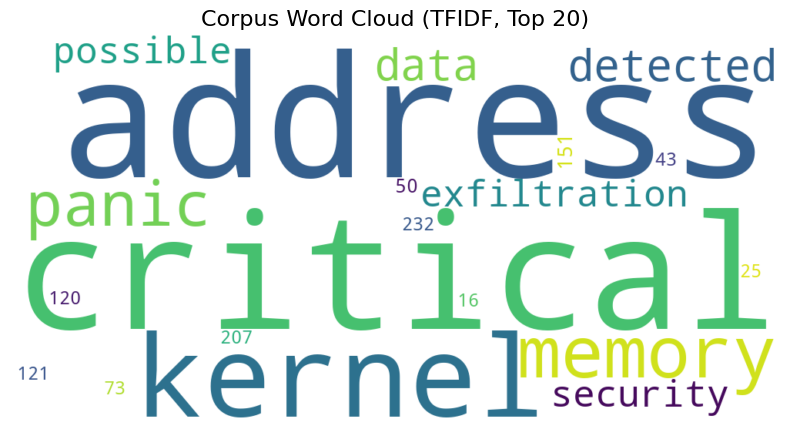

In [100]:
word_cloud(outliers_df, "tfidf")